# Figure4

In [1]:
from pathlib import Path

FIGURE_OUTPUT_DIR = Path("results/Figure4")
FIGURE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from functions.load_data import loadTrials, loadTrialsM, human_generalization_sessions
from functions.utils import first_trial_accuracy
from functions.plotting import set_paper_theme

set_paper_theme()


### Human data

In [3]:
df = human_generalization_sessions()

In [4]:
task_names = ["Outdoor vs. Indoor","Big vs. Small(THINGS)","Big vs. Small(Konkle)","Fire related vs. Water related(THINGS)","Eastern vs. Western"]

In [5]:

CRs = []
SEs = []
for task in task_names:
    df_task = df[df["task_label"] == task]
    cr = []
    print(f"{task}")
    for i in range(len(df_task)):
        session = df_task.iloc[i]
        subj = session["subject"]
        datafile = f"data_behavior/Human/{session['task']}/{session['filename']}"
        trials = loadTrials(datafile)
        trials_gen = [tr for tr in trials if tr["trial_type"]=="gen" ]
        _cr = np.mean([tr["result"]=="CORRECT" for tr in trials_gen])
        cr.append(_cr)
        print(f"{subj} {np.mean(_cr):.4} {len(trials_gen)}")
    print(f"{np.mean(cr):.4}")

    CRs.append(np.mean(cr))
    SEs.append(np.std(cr)/np.sqrt(len(cr)))


Outdoor vs. Indoor
048 0.9801 151
050 0.9776 134
058 0.9839 124
060 0.984 125
062 0.9704 135
063 0.9787 141
064 0.9669 121
065 0.992 125
066 0.964 139
0.9775
Big vs. Small(THINGS)
048 1.0 109
050 1.0 103
058 0.9818 110
059 0.9901 101
060 0.9905 105
063 0.9706 102
064 0.97 100
065 0.9922 128
066 0.9908 109
0.9873
Big vs. Small(Konkle)
048 0.9623 106
050 0.9714 105
058 0.9712 104
059 0.9519 104
063 0.963 108
064 0.8241 108
065 0.94 100
066 0.9444 126
070 0.9167 120
0.9383
Fire related vs. Water related(THINGS)
048 0.949 98
050 0.95 100
058 0.9429 105
063 0.9043 94
064 0.713 108
066 0.9588 97
068 0.9417 103
069 0.9626 107
070 0.883 94
0.9117
Eastern vs. Western
048 0.9664 119
050 0.972 107
058 0.9576 118
059 0.9554 112
060 0.9238 105
061 0.9712 104
063 0.9643 112
064 0.8627 102
066 0.9358 109
0.9455


### Monkey data

In [6]:
task_names = ["outdoor_vs_indoor_gen","big_vs_small_gen","big_vs_small_Konkle_gen","fire related_vs_water related_gen","eastern_vs_western_gen"]

In [7]:

CR = []
SE = []
for task in task_names:
    cr = []
    for monkey in ["Elsa","Judy","Olaf"]:
        trials,_ = loadTrialsM(task,monkey)
        trials_gen = [trial for trial in trials if trial["trial_type"]=="gen"]
        _,_,res = first_trial_accuracy(trials_gen)
        cr.append(res)

    print(f"{np.mean(np.mean(cr,axis=0)):.4} {task}")

    cr_avg = np.mean(cr,axis=0)
    CR.append(np.mean(cr_avg))
    SE.append(np.sqrt(np.mean(cr_avg)*(1-np.mean(cr_avg))/len(cr_avg)))


0.7722 outdoor_vs_indoor_gen
0.8 big_vs_small_gen
0.7533 big_vs_small_Konkle_gen
0.5688 fire related_vs_water related_gen
0.4767 eastern_vs_western_gen


### Plot

In [8]:
CRs

[0.9775200065262228,
 0.9873327561736528,
 0.9383241992885599,
 0.9116845580059345,
 0.9454563813052835]

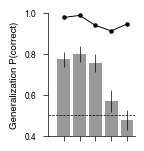

In [9]:
fig, ax = plt.subplots()
fig.set(figheight=105/75,figwidth=100/75)


ax.bar(range(len(task_names)),CR,yerr=SE,color="#999999",error_kw={"linewidth":0.5})
ax.plot(range(len(task_names)),CRs,color="black",linewidth=0.7,zorder=0)
ax.scatter(range(len(task_names)),CRs,color="black",s=5,zorder=1)

ax.axhline(0.5,color="black",linestyle="dashed",linewidth=0.5)
ax.set_xticks(range(len(task_names)))
ax.set_xticklabels([])
ax.set_yticks([0.4,0.6,0.8,1.])

ax.set_ylabel("Generalization P(correct)")
ax.set_xlim(-1,len(task_names)-0.5)
ax.set_ylim(0.4,1.0)

ax.tick_params(axis='both', which='major', pad=5)

plt.savefig(FIGURE_OUTPUT_DIR / "conceptual_generalization_human_monkey.pdf")
plt.show()